# 第一章 python数据模型（对象模型）
1. python风格(pythonic)。为什么是 `len(collection)` 而不是 `collection.len()` ??
2. 特殊方法？

## 1.1 特殊方法的强大
通过一个例子，表明`__getitem__`和 `__len__`

In [4]:
import collections

Card = collections.namedtuple('Card', ['rank', 'suit']) 

class FrenchDeck:
    ranks = [ str(n) for n in range(2, 11)] + list('JQKA')
    suits = 'spades diamonds clubs hearts'.split() # 花色

    def __init__(self):
        self._cards = [Card(rank, suit) for suit in self.suits 
                                        for rank in self.ranks]
    def __len__(self):
        return len(self._cards)
    def __getitem__(self, position):
        return self._cards[position]

首先，`namedtuple` 创建一个只有类属性，没有类方法的简单类。这可以用来创建一些数据库记录。我们可以很快得到一个对象

In [5]:
card = Card('7', 'diamonds')
print(card)

Card(rank='7', suit='diamonds')


*FrenchDeck* 像任何标准序列类型一样，我们可以使用`len()` 访问：

In [6]:
deck = FrenchDeck()
print(len(deck))

52


同样的，我们可以通过下标进行访问：

In [7]:
print(deck[2])
print(deck[-1])

Card(rank='4', suit='spades')
Card(rank='A', suit='hearts')


此外，如果我们需要随机抽取，不需要自己实现。python的内置函数`random.choice` 可以从序列中直接随机抽取一个元素：

In [8]:
from random import choice
print(choice(deck))

Card(rank='9', suit='diamonds')


以上，实现特殊方法，为我们带来两个好处：
- 我们不必为 `.size()` 之类的方法命名烦恼。 都是 `len()`。
- 可以直接使用 python 内置的强大函数和工具库，比如 `random.choice`。

由于实现了`__getitem__` 方法，我们的`FrenchDeck` 类自动支持切片和迭代

In [14]:
deck[:3]

[Card(rank='2', suit='spades'),
 Card(rank='3', suit='spades'),
 Card(rank='4', suit='spades')]

In [9]:
for c in deck:
    print(c)
for c in reversed(deck):
    print(c)

Card(rank='2', suit='spades')
Card(rank='3', suit='spades')
Card(rank='4', suit='spades')
Card(rank='5', suit='spades')
Card(rank='6', suit='spades')
Card(rank='7', suit='spades')
Card(rank='8', suit='spades')
Card(rank='9', suit='spades')
Card(rank='10', suit='spades')
Card(rank='J', suit='spades')
Card(rank='Q', suit='spades')
Card(rank='K', suit='spades')
Card(rank='A', suit='spades')
Card(rank='2', suit='diamonds')
Card(rank='3', suit='diamonds')
Card(rank='4', suit='diamonds')
Card(rank='5', suit='diamonds')
Card(rank='6', suit='diamonds')
Card(rank='7', suit='diamonds')
Card(rank='8', suit='diamonds')
Card(rank='9', suit='diamonds')
Card(rank='10', suit='diamonds')
Card(rank='J', suit='diamonds')
Card(rank='Q', suit='diamonds')
Card(rank='K', suit='diamonds')
Card(rank='A', suit='diamonds')
Card(rank='2', suit='clubs')
Card(rank='3', suit='clubs')
Card(rank='4', suit='clubs')
Card(rank='5', suit='clubs')
Card(rank='6', suit='clubs')
Card(rank='7', suit='clubs')
Card(rank='8', sui

In [14]:
Card(rank='2', suit='spades') in deck

True

可以进行排序吗？使用`sorted()` 函数：

In [11]:

for c in sorted(deck, key = lambda x: x.rank):
    print(c)

Card(rank='10', suit='spades')
Card(rank='10', suit='diamonds')
Card(rank='10', suit='clubs')
Card(rank='10', suit='hearts')
Card(rank='2', suit='spades')
Card(rank='2', suit='diamonds')
Card(rank='2', suit='clubs')
Card(rank='2', suit='hearts')
Card(rank='3', suit='spades')
Card(rank='3', suit='diamonds')
Card(rank='3', suit='clubs')
Card(rank='3', suit='hearts')
Card(rank='4', suit='spades')
Card(rank='4', suit='diamonds')
Card(rank='4', suit='clubs')
Card(rank='4', suit='hearts')
Card(rank='5', suit='spades')
Card(rank='5', suit='diamonds')
Card(rank='5', suit='clubs')
Card(rank='5', suit='hearts')
Card(rank='6', suit='spades')
Card(rank='6', suit='diamonds')
Card(rank='6', suit='clubs')
Card(rank='6', suit='hearts')
Card(rank='7', suit='spades')
Card(rank='7', suit='diamonds')
Card(rank='7', suit='clubs')
Card(rank='7', suit='hearts')
Card(rank='8', suit='spades')
Card(rank='8', suit='diamonds')
Card(rank='8', suit='clubs')
Card(rank='8', suit='hearts')
Card(rank='9', suit='spades'

## 1.2 使用特殊方法
- 特殊方法是由解释器调用的。
- 很多特殊方法调用是隐式的。比如`for i in x:` 背后是对象的 `__iter__()` 方法 / `iter(x)`。
- 

### 1.2.1 模拟数值类型，可以计算
- 可以让自定义对象进行运算

例子：一个向量类，可以进行向量加法和点积运算：

> python内置的complex表示二维向量。

In [2]:
# 二维向量
from math import hypot
class Vector:
    def __init__(self, x = 0, y = 0):
        self.x = x
        self.y = y
    def __repr__(self):
        return 'Vector (%r, %r)' % (self.x, self.y)  # %r 格式化符号
    def __abs__(self):
        return hypot(self.x, self.y) # sqrt(x*x + y*y)
    def __add__(self, other):
        x = self.x + other.x
        y = self.y + other.y
        return Vector(x, y)
    def __mul__(self, scalar):
        return Vector(self.x * scalar, self.y * scalar)
    def __bool__(self):
        return bool(self.x or self.y)

In [3]:
Vector(1, 2) + Vector(1, 2)

Vector (2, 4)

In [4]:
Vector(1, 2) * 3

Vector (3, 6)

In [6]:
abs(Vector(1, 2))

2.23606797749979

### 1.2.2 对象的字符串表示形式
- `__str__` 在使用 `print()` 或 `str()` 时调用，返回的字符串对用户友好
- `__repr__` 在使用 `repr()` 时调用，对开发者友好，尽可能表达出对象的细节。
- 如果只想要实现一个，优先实现 `__repr__`，因为 `__str__` 默认会调用 `__repr__`。

### 1.2.3 自定义bool值
- 我们可以通过实现 `__bool__` 方法，来定义对象的布尔值。让其返回 `True` 或 `False`。

## 1.3 特殊方法一览

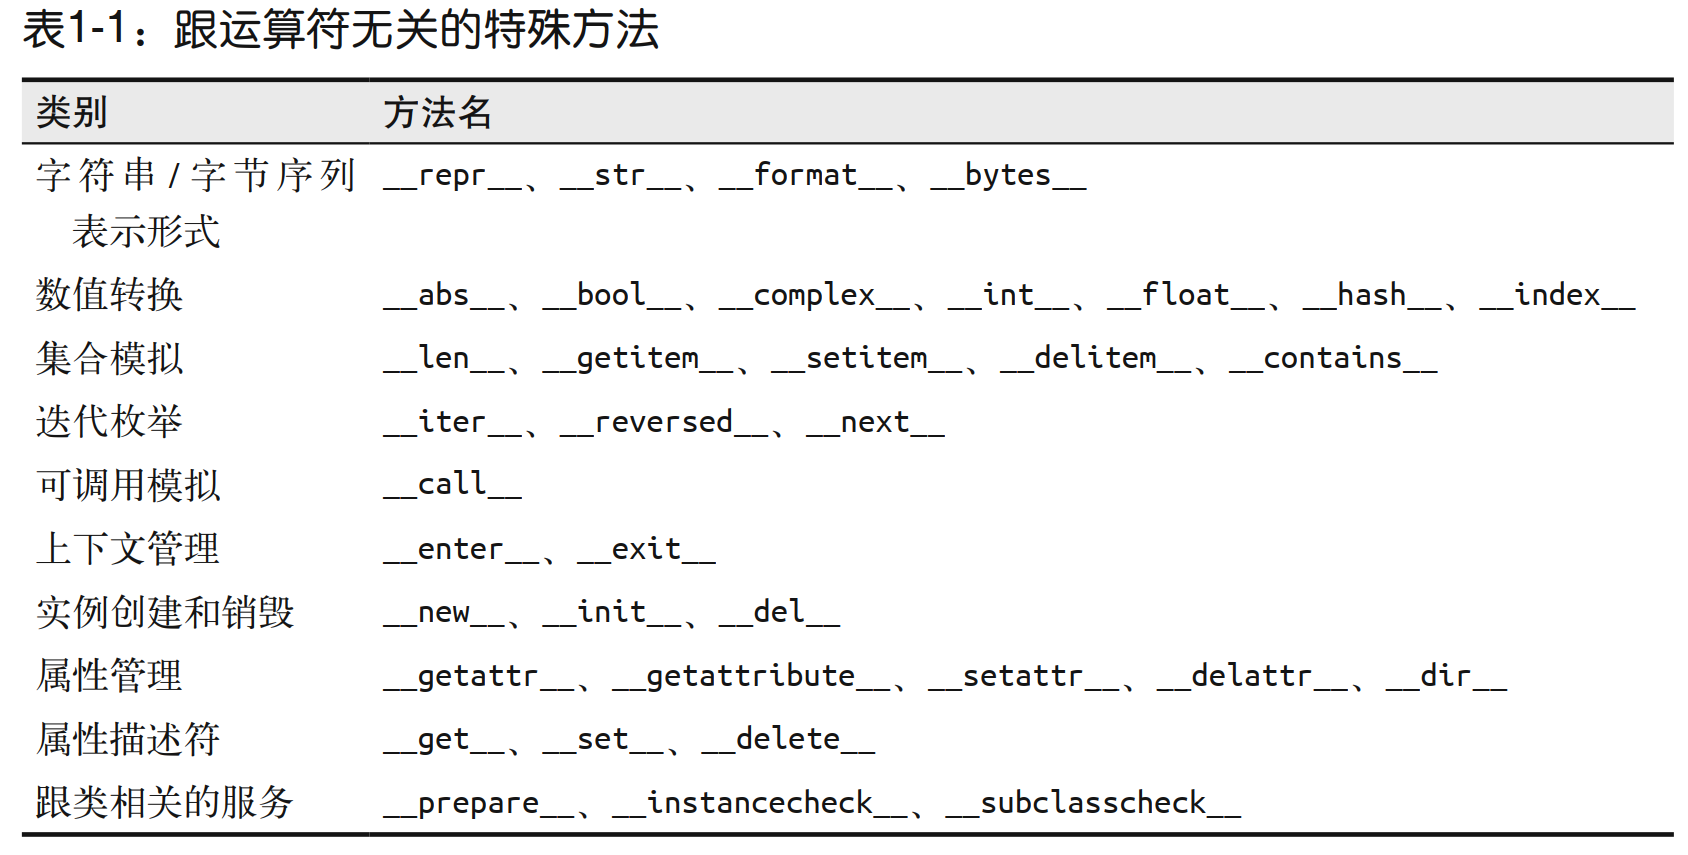
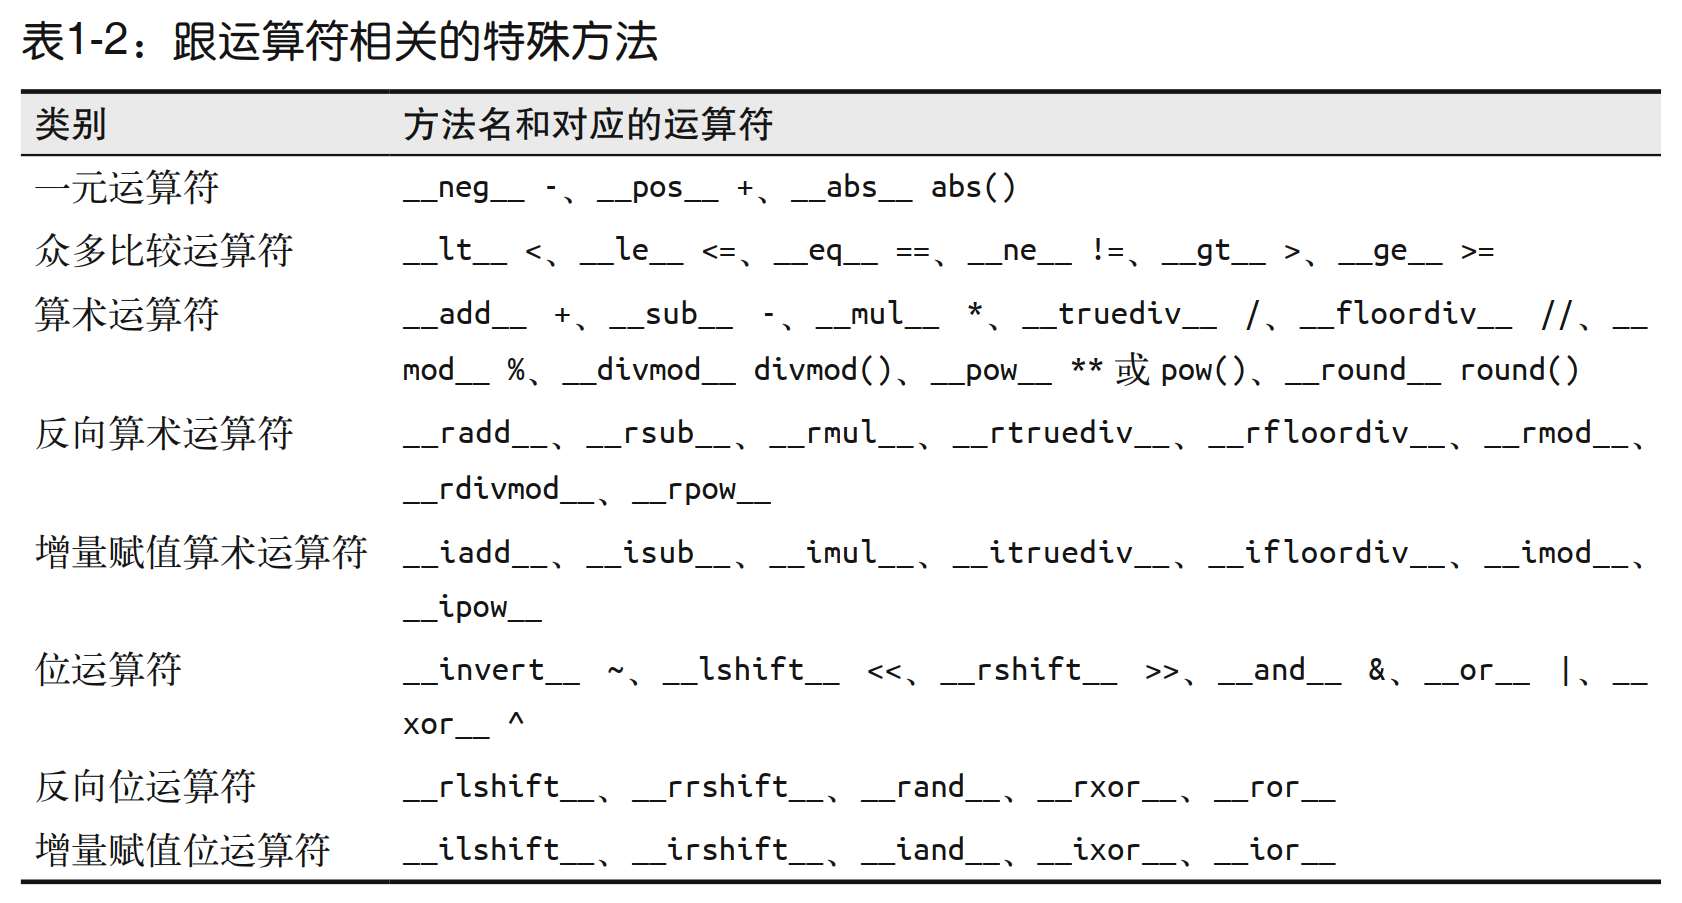  

# 第二章 序列构成数组

## 2.1 内置的序列类型分类
是否可以存放不同类数据：
- 容器序列：*list, turple, collections.queue*。 不同类型数据, 存放的是引用
- 扁平序列: *str, bytes, bytearray, memoryview, array.array*。 同一类型，连续内存空间，存储基础类型的值

是否可被修改：
- 不可变序列：*turple, str, bytes*
- 可变序列： *list, collections.queue,  bytearray, memoryview, array.array*



不可变(Sequence)和可变序列(MutuableSequence)区别：
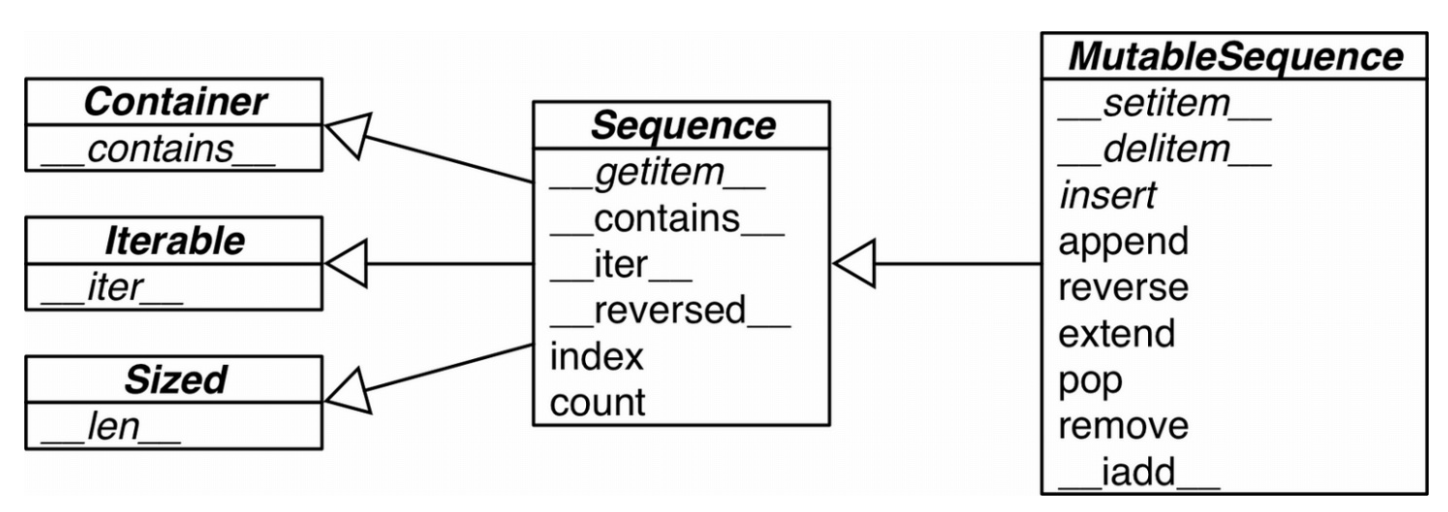
- 列举了`collections.abc` 中的几个类。超类在左边，斜体表示抽象类和方法

## 2.2 列表推导和生成器表达式
- 列表推导：生成一个列表
- 生成器表达式：创建其他任何类型的序列

In [33]:
symbols = '$¢£¥€¤'
codes = [ord(symbol) for symbol in symbols]
codes

[36, 162, 163, 165, 8364, 164]

In [39]:
beyond_ascii = [ ord(symbol) for symbol in symbols if ord(symbol) > 127]
beyond_ascii

[162, 163, 165, 8364, 164]

In [44]:
beyond_ascii = list(filter(lambda symbol : symbol > 128, map(ord, symbols)))
beyond_ascii

[162, 163, 165, 8364, 164]

### 2.2.3 笛卡尔积

In [2]:
colors = ['black', 'white']
sizes = ['S', 'M', 'L']
tshirts = [ (color, size) for color in colors for size in sizes]
print(tshirts)

[('black', 'S'), ('black', 'M'), ('black', 'L'), ('white', 'S'), ('white', 'M'), ('white', 'L')]


### 2.2.4 生成器表达式
- 生成器表达式用 `()` 括起来，而不是 `[]`。
- 逐个生成元素，而不是一次性创建整个列表，从而节省内存。

In [4]:
symbols = '$¢£¥€¤'
tuple(ord(symbol) for symbol in symbols)

(36, 162, 163, 165, 8364, 164)

In [5]:
import array
array.array('I', (ord(symbol) for symbol in symbols))

array('I', [36, 162, 163, 165, 8364, 164])

## 2.3 元组
- 元组不仅仅是不可变列表，更是记录：结构化数据，每个位置都有固定含义
1. *拆包
2. `*`处理剩余元素： 如`*args`

### 2.3.1 元组作为记录
- 元组可以用来表示记录，比如数据库中的一行数据。每个**位置**都有特定含义。

### 2.3.2 元组拆包
- 把`()`中的元素依次赋值给变量
- `%` 把元组拆包用于格式化字符串
- `*` 把可迭代对象拆包成位置参数传递给函数
- `*` 也可以用在赋值语句中，收集剩余元素

In [8]:
name, usrid, score = ('dong', 1001, 100.2)
print(name, usrid, score)

dong 1001 100.2


In [9]:
student1 = ('zhang', 1003, 120.2)
print(*student1) # 拆包

zhang 1003 120.2


In [10]:
import os
path, filename = os.path.split('/home/dong/.viminfo')
print(path, filename)

/home/dong .viminfo


In [11]:
a,b,*rest = range(5)
print(rest)

[2, 3, 4]


In [10]:
a,*rest, b = range(10)
print(rest)

[1, 2, 3, 4, 5, 6, 7, 8]


可以看到， *可以出现在任意位置

### 2.3.3 嵌套元组拆包


In [13]:
metro_areas = [
    ('Tokyo', 'JP', 36.933, (35.689722, 139.691667)),
    ('Delhi NCR', 'IN', 21.935, (28.613889, 77.208889)),
    ('Mexico City', 'MX', 20.142, (19.433333, -99.133333)),
    ('New York-Newark', 'US', 20.104, (40.808611, -74.020386)),
    ('Sao Paulo', 'BR', 19.649, (-23.547778, -46.635833)),
]
print('{:15} | {:^9} | {:^9}'.format('City', 'Lat.', 'Long.'))
for name, cc, pop, (latitude, longitude) in metro_areas:
    if longitude <= 0:
        print('{:15} | {:9.4f} | {:9.4f}'.format(name, latitude, longitude))

City            |   Lat.    |   Long.  
Mexico City     |   19.4333 |  -99.1333
New York-Newark |   40.8086 |  -74.0204
Sao Paulo       |  -23.5478 |  -46.6358


### 2.3.4 具名元组
- 元组可以记录，但是缺少字段名。 
- `collections.namedtuple` 是一个工厂函数，可以创建带字段名的**元组子类**。

In [16]:
from collections import namedtuple
City = namedtuple('City', ['name', 'country', 'population', 'coordinates'])
tokyo = City('Tokyo', 'JP', '35.33', (41.6666, 30.33333))
print(tokyo)

City(name='Tokyo', country='JP', population='35.33', coordinates=(41.6666, 30.33333))


除了从元组继承的属性之外，具名元组还有一些额外的属性和方法：
- `_fields`：一个包含字段名称的元组。
- `_make(iterable)`：一个类方法，用于从可迭代对象创建
- `_asdict()`：把具名元组以`collections.OrderedDict` 的形式返回,友好展现

In [18]:
print(City._fields) # 字段

('name', 'country', 'population', 'coordinates')


In [19]:
City._make(('New York', 'US', 20.104, (40.808611, -74.020386)))

City(name='New York', country='US', population=20.104, coordinates=(40.808611, -74.020386))

In [20]:
for k,v in tokyo._asdict().items(): # 友好打印
    print(k,':', v)

name : Tokyo
country : JP
population : 35.33
coordinates : (41.6666, 30.33333)


### 2.3.5 元组作为不可变列表

## 2.4 切片
- list, tuple, str 等内置序列类型都支持切片操作。

### 2.4.1 为什么切片区间忽略最后一个元素
- 只有终止位置，迅速知道有几个元素：`range(3)` , `mylist[:3]` 表示含3个元素
- 起止都知道时候，迅速知道元素个数：`end-start`为元素个数，`mylist[start:end]`
- 可以很快地分割为不重叠两部分： `mylist[:mid]` 和 `mylist[mid:]`

In [21]:
l = [10, 20, 30, 40]
print(l[:2], l[2:])

[10, 20] [30, 40]


### 2.4.2 带step的切片
- `start:stop:step`

In [27]:
s = 'bicycle'
print(s[::3])  # 'bye'
print(s[::-1])  # 'elcycib'

bye
elcycib


切片对象slice

In [31]:
invoice = """
0....6................................40........52...55........
1909  Pimoroni PiBrella                 $17.50  3   $52.50
1489  6mm Tactile Switch x20            $4.95   2   $9.90
1510  Panavise Jr. - PV-201             $28.00  1   $28.00
1601  PiTFT Plus 320x240                $34.95  1   $34.95
"""
SKU = slice(0, 6)
UNIT_PRICE = slice(40, 52)
QUANTITY = slice(52, 55)
for line in invoice.split('\n'):
    print(line[SKU], line[UNIT_PRICE], line[QUANTITY])

  
0....6 ........52.. .55
1909   $17.50  3    $52
1489   $4.95   2    $9.
1510   $28.00  1    $28
1601   $34.95  1    $34
  


### 2.4.3 多维切片和忽略
- `[]`可以用逗号分隔多个切片对象，表示多维切片。
- *numPy*就用这个特性，如`a[1,2]` , `a[1:2, 3:4]`
- 这需要`__getitem__` 方法支持多个参数，`__getitem__(self, key1, key2, ...)`. 调用时候传入`__getitem__((x,y))`
- python内置类型不支持多维切片。只支持一维切片。

- `...`省略号，可以用在多维切片中，表示多个`:`。
  - 是一个Ellipsis 对象 , 一方面可以用于切片，另一方面可以用于函数参数，表示任意数量位置参数。
  - `f(a, b, c, ...)` 传入任意数量的位置参数； 对于一个4为数组，`a[1,...., 5]` 等价于 `a[1,:, :, :, 5]`

### 2.4.4 给切片赋值
- 把切片放在左侧，或者作为del 的对象。
- 序列嫁接、切除、就地修改

In [44]:
l = list(range(10))
print(l)

l[2:5] = [20, 30]
print(l)

del l[5:7]
print(l)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[0, 1, 20, 30, 5, 6, 7, 8, 9]
[0, 1, 20, 30, 5, 8, 9]


切片赋值只能通过序列，不能单个值。且数量匹配

In [46]:
l[2:5] = [100]
print(l)

[0, 1, 100]


## 2.5 序列拼接 使用+ 和 *
- 拼接操作的序列不会被修改，会新建一个序列返回结果。

In [50]:
l = [10, 20, 30, 40]
print(l * 2)
print(l + [50, 60])
print(l)

[10, 20, 30, 40, 10, 20, 30, 40]
[10, 20, 30, 40, 50, 60]
[10, 20, 30, 40]


## 2.6 序列增量赋值 += 和 *=

## 2.7 list.sort 和 内置 sorted
- `list.sort`原地修改, `sorted()` 内置函数返回一个新列表
- 两者都接受 `key` 和 `reverse` 参数。 `key` 是一个函数名，如`len`，`str.lower` 等。

>  通常地，原地修改的都会返回None。 如`random.shuffle()`

In [53]:
fruit = ['grape', 'raspberry', 'apple', 'banana']
fruit.sort()
print(fruit)

['apple', 'banana', 'grape', 'raspberry']


In [54]:
fruit = ['grape', 'raspberry', 'apple', 'banana']
print(sorted(fruit))

['apple', 'banana', 'grape', 'raspberry']


In [56]:
fruit = ['grape', 'raspberry', 'apple', 'banana']
fruit.sort(key=len)
print(fruit)

['grape', 'apple', 'banana', 'raspberry']


## 2.8 bisect模块搜索/插入 已排序的序列
- `bisect` 模块提供`bisect`和`insort`函数，实现了二分查找算法，可以在已排序的序列中快速搜索和插入元素。

### 2.8.1 bisect 搜索

In [58]:
import bisect
def grade(score, breakpoints = [60, 70, 80, 90], grades = 'FDCBA'):
    i = bisect.bisect(breakpoints, score)
    return grades[i]
print(grade(33), grade(99), grade(77))

F A C


### 2.8.2 insort 插入

In [59]:
import bisect
import random
random.seed(1729)

l = []
for i in range(7):
    new_item = random.randrange(1, 101)
    bisect.insort(l, new_item)
    print('%2d ->' % new_item, l)

84 -> [84]
 6 -> [6, 84]
53 -> [6, 53, 84]
65 -> [6, 53, 65, 84]
59 -> [6, 53, 59, 65, 84]
22 -> [6, 22, 53, 59, 65, 84]
86 -> [6, 22, 53, 59, 65, 84, 86]


## 2.9 列表不是首选的情况
- 如存储大量浮点数，array更合适
- 如先进先出，deque双端队列更合适
- 如set不重复

### 2.9.1 array存储大量数值
- 屏蔽了一些没用的方法，如不支持`.sort()`
- 增加了一些快速方法，如 `.tofile()`, `.fromfile()`
- 创建数组时候应该给定一个类型码。
  - `b`表示`signed char` (1字节)，
  - `u`表示`unicode character` (2字节)，
  - `h`表示`signed short` (2字节)，
  - `i`表示`signed int` (4字节)，
  - `f`表示`float` (4字节)，
  - `d`表示`double` (8字节) 
- 

例子，创建大量随机浮点数，并存储到文件，然后读取回来

In [61]:
from array import array
import random
floats = array('d', (random.random() for i in range(10**7)))

In [64]:
with open('floats.bin', 'wb') as f:
    floats.tofile(f)

In [65]:
with open('floats.bin', 'rb') as f:
    floats2 = array('d')
    floats2.fromfile(f, 10**7)

In [66]:
print(floats[-1], floats2[-1])

0.1288579230853678 0.1288579230853678


In [67]:
floats2 == floats

True

### 2.9.2 内存视图memoryview
- 在不需要复制内容的情况下，在数据结构之间共享内存。
- 类似c语言的类型转换（内存访问）

这个例子，描述了以字节的粒度修改访问元素
- 创建一个`memoryview` 对象，指向一个`array` 对象
- 使用`cast()` 方法，把内存视图转换为不同的类型

In [72]:
number = array('h', [-2, -1, 0, 1, 2]) # 创建一个短整型数组
memv = memoryview(number)
print(len(memv))
print(memv[0])

5
-2


In [73]:
mem_oct = memv.cast('B') # 无符号字节
print(len(mem_oct))

10


In [74]:
mem_oct.tolist()

[254, 255, 255, 255, 0, 0, 1, 0, 2, 0]

In [75]:
mem_oct[2] = 4
number

array('h', [-2, -252, 0, 1, 2])

### 2.9.3 numpy和scipy